# Audio perturbations
Author: Martine Klep
Date: 03-05-2026

This script implements a pipeline for generating perturbed versions of the selected audio datasets from the TAME dataset. The perturbations are applied to both the full dataset and the separate pain-group datasets.

Steps:
1. Load and define datasets: for the full dataset and for each paingroup
2. Define perturbation types and levels: intensity, gaussian, pink and low pass filtering
3. Collect and load audio files
4. Apply perturbations
5. Perturbation methods:
   - Intensity: adjust amplitude
   - Gaussian: add randoms noise
   - Pink noise: add random noise, more at lower frequencies
   - low pass filtering: removes high frequency using butterworth filter
6. Create output and save 

In [ ]:
# TAME/
#├── audio files (.wav)
#│   ├── original_audiofiles_20_pain/
#│   ├── original_audiofiles_20_pain_1_to_4/
#│   ├── original_audiofiles_20_pain_5_to_6/
#│   ├── original_audiofiles_20_pain_7_to_10/
#│   │
#│   ├── wiener_audiofiles_pain/
#│   ├── wiener_group_1_to_4_audiofiles_pain/
#│   ├── wiener_group_5_to_6_audiofiles_pain/
#│   └── wiener_group_7_to_10_audiofiles_pain/
#│
#├── perturbations (original)
#│   ├── original_intensity_pain/
#│   │   ├── -6dB/
#│   │   ├── -3dB/
#│   │   ├── +3dB/
#│   │   └── +6dB/
#│   │
#│   ├── original_gaussian_noise_pain/
#│   │   ├── low_gaussian_noise/
#│   │   ├── medium_gaussian_noise/
#│   │   ├── high_gaussian_noise/
#│   │   └── very_high_gaussian_noise/
#│   │
#│   ├── original_pink_noise_pain/
#│   │   ├── low_pink_noise/
#│   │   ├── medium_pink_noise/
#│   │   ├── high_pink_noise/
#│   │   └── very_high_pink_noise/
#│   │
#│   ├── original_lowpass_pain/
#│   │   ├── low_lowpass/
#│   │   ├── medium_lowpass/
#│   │   ├── high_lowpass/
#│   │   └── very_high_lowpass/
#│   │
#│   ├── original_group_1_to_4_intensity_pain/
#│   │   ├── -6dB/
#│   │   ├── -3dB/
#│   │   ├── +3dB/
#│   │   └── +6dB/
#│   │
#│   ├── original_group_1_to_4_gaussian_noise_pain/
#│   │   ├── low_gaussian_noise/
#│   │   ├── medium_gaussian_noise/
#│   │   ├── high_gaussian_noise/
#│   │   └── very_high_gaussian_noise/
#│   │
#│   ├── original_group_1_to_4_pink_noise_pain/
#│   │   ├── low_pink_noise/
#│   │   ├── medium_pink_noise/
#│   │   ├── high_pink_noise/
#│   │   └── very_high_pink_noise/
#│   │
#│   ├── original_group_1_to_4_lowpass_pain/
#│   │   ├── low_lowpass/
#│   │   ├── medium_lowpass/
#│   │   ├── high_lowpass/
#│   │   └── very_high_lowpass/
#│   │
#│   ├── original_group_5_to_6_intensity_pain/
#│   │   ├── -6dB/
#│   │   ├── -3dB/
#│   │   ├── +3dB/
#│   │   └── +6dB/
#│   │
#│   ├── original_group_5_to_6_gaussian_noise_pain/
#│   │   ├── low_gaussian_noise/
#│   │   ├── medium_gaussian_noise/
#│   │   ├── high_gaussian_noise/
#│   │   └── very_high_gaussian_noise/
#│   │
#│   ├── original_group_5_to_6_pink_noise_pain/
#│   │   ├── low_pink_noise/
#│   │   ├── medium_pink_noise/
#│   │   ├── high_pink_noise/
#│   │   └── very_high_pink_noise/
#│   │
#│   ├── original_group_5_to_6_lowpass_pain/
#│   │   ├── low_lowpass/
#│   │   ├── medium_lowpass/
#│   │   ├── high_lowpass/
#│   │   └── very_high_lowpass/
#│   │
#│   ├── original_group_7_to_10_intensity_pain/
#│   │   ├── -6dB/
#│   │   ├── -3dB/
#│   │   ├── +3dB/
#│   │   └── +6dB/
#│   │
#│   ├── original_group_7_to_10_gaussian_noise_pain/
#│   │   ├── low_gaussian_noise/
#│   │   ├── medium_gaussian_noise/
#│   │   ├── high_gaussian_noise/
#│   │   └── very_high_gaussian_noise/
#│   │
#│   ├── original_group_7_to_10_pink_noise_pain/
#│   │   ├── low_pink_noise/
#│   │   ├── medium_pink_noise/
#│   │   ├── high_pink_noise/
#│   │   └── very_high_pink_noise/
#│   │
#│   └── original_group_7_to_10_lowpass_pain/
#│       ├── low_lowpass/
#│       ├── medium_lowpass/
#│       ├── high_lowpass/
#│       └── very_high_lowpass/
#│
#└── perturbations (wiener)
#    ├── wiener_intensity_pain/
#    │   ├── -6dB/
#    │   ├── -3dB/
#    │   ├── +3dB/
#    │   └── +6dB/
#    │
#    ├── wiener_gaussian_noise_pain/
#    │   ├── low_gaussian_noise/
#    │   ├── medium_gaussian_noise/
#    │   ├── high_gaussian_noise/
#    │   └── very_high_gaussian_noise/
#    │
#    ├── wiener_pink_noise_pain/
#    │   ├── low_pink_noise/
#    │   ├── medium_pink_noise/
#    │   ├── high_pink_noise/
#    │   └── very_high_pink_noise/
#    │
#    ├── wiener_lowpass_pain/
#    │   ├── low_lowpass/
#    │   ├── medium_lowpass/
#    │   ├── high_lowpass/
#    │   └── very_high_lowpass/
#    │
#    ├── wiener_group_1_to_4_intensity_pain/
#    │   ├── -6dB/
#    │   ├── -3dB/
#    │   ├── +3dB/
#    │   └── +6dB/
#    │
#    ├── wiener_group_1_to_4_gaussian_noise_pain/
#    │   ├── low_gaussian_noise/
#    │   ├── medium_gaussian_noise/
#    │   ├── high_gaussian_noise/
#    │   └── very_high_gaussian_noise/
#    │
#    ├── wiener_group_1_to_4_pink_noise_pain/
#    │   ├── low_pink_noise/
#    │   ├── medium_pink_noise/
#    │   ├── high_pink_noise/
#    │   └── very_high_pink_noise/
#    │
#    ├── wiener_group_1_to_4_lowpass_pain/
#    │   ├── low_lowpass/
#    │   ├── medium_lowpass/
#    │   ├── high_lowpass/
#    │   └── very_high_lowpass/
#    │
#    ├── wiener_group_5_to_6_intensity_pain/
#    │   ├── -6dB/
#    │   ├── -3dB/
#    │   ├── +3dB/
#    │   └── +6dB/
#    │
#    ├── wiener_group_5_to_6_gaussian_noise_pain/
#    │   ├── low_gaussian_noise/
#    │   ├── medium_gaussian_noise/
#    │   ├── high_gaussian_noise/
#    │   └── very_high_gaussian_noise/
#    │
#    ├── wiener_group_5_to_6_pink_noise_pain/
#    │   ├── low_pink_noise/
#    │   ├── medium_pink_noise/
#    │   ├── high_pink_noise/
#    │   └── very_high_pink_noise/
#    │
#    ├── wiener_group_5_to_6_lowpass_pain/
#    │   ├── low_lowpass/
#    │   ├── medium_lowpass/
#    │   ├── high_lowpass/
#    │   └── very_high_lowpass/
#    │
#    ├── wiener_group_7_to_10_intensity_pain/
#    │   ├── -6dB/
#    │   ├── -3dB/
#    │   ├── +3dB/
#    │   └── +6dB/
#    │
#    ├── wiener_group_7_to_10_gaussian_noise_pain/
#    │   ├── low_gaussian_noise/
#    │   ├── medium_gaussian_noise/
#    │   ├── high_gaussian_noise/
#    │   └── very_high_gaussian_noise/
#    │
#    ├── wiener_group_7_to_10_pink_noise_pain/
#    │   ├── low_pink_noise/
#    │   ├── medium_pink_noise/
#    │   ├── high_pink_noise/
#    │   └── very_high_pink_noise/
#    │
#    └── wiener_group_7_to_10_lowpass_pain/
#        ├── low_lowpass/
#        ├── medium_lowpass/
#        ├── high_lowpass/
#        └── very_high_lowpass/

Without Wiener

In [ ]:
from pathlib import Path
import numpy as np
from scipy.io import wavfile
from scipy.signal import butter, sosfiltfilt

# Paths
DATA_PATH = Path(r"C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht\TAME")

INPUT_DATASETS = {
    "original": {
        "input_dir": DATA_PATH / "original_audiofiles_20_pain",
    },
    "original_pain_group_1_to_4": {
        "input_dir": DATA_PATH / "original_audiofiles_20_pain_1_to_4",
    },
    "original_pain_group_5_to_6": {
        "input_dir": DATA_PATH / "original_audiofiles_20_pain_5_to_6",
    },
    "original_pain_group_7_to_10": {
        "input_dir": DATA_PATH / "original_audiofiles_20_pain_7_to_10",
    },
}

# Perturbations 
PERTURBATION_TEMPLATES = {
    "intensity": {
        "levels": {
            "-6dB": -6,
            "-3dB": -3,
            "+3dB": 3,
            "+6dB": 6,
        },
    },
    "gaussian_noise": {
        "levels": {
            "low_gaussian_noise": 0.005,
            "medium_gaussian_noise": 0.02,
            "high_gaussian_noise": 0.05,
            "very_high_gaussian_noise": 0.1,
        },
    },
    "pink_noise": {
        "levels": {
            "low_pink_noise": 0.005,
            "medium_pink_noise": 0.02,
            "high_pink_noise": 0.05,
            "very_high_pink_noise": 0.1,
        },
    },
    "lowpass": {
        "levels": {
            "low_lowpass": 6000,
            "medium_lowpass": 5000,
            "high_lowpass": 4000,
            "very_high_lowpass": 3000,
        },
        "filter_order": 4,
    },
}

# Functions 
def get_group_suffix(dataset_name):
    """
    Get the group suffix for the output directory based on the dataset name. This function maps the dataset name to a specific suffix that indicates which group of pain levels it corresponds to. If the dataset name is "original", it returns an empty string, indicating that it includes all pain levels. For the other dataset names, it returns a suffix that specifies the range of pain levels included in that dataset.
    """
    if dataset_name == "original":
        return ""
    if dataset_name == "original_pain_group_1_to_4":
        return "_group_1_to_4"
    if dataset_name == "original_pain_group_5_to_6":
        return "_group_5_to_6"
    if dataset_name == "original_pain_group_7_to_10":
        return "_group_7_to_10"
    raise ValueError(f"Unknown dataset_name: {dataset_name}")


def build_output_dir(dataset_name, perturbation_type):
    """
    Build the output directory path based on the dataset name and perturbation type. This function constructs the output directory path by combining the base data path with a specific naming convention that includes the group suffix (derived from the dataset name) and the perturbation type. The resulting path indicates where the perturbed audio files will be saved for each combination of dataset and perturbation.
    """
    group_suffix = get_group_suffix(dataset_name)
    return DATA_PATH / f"original{group_suffix}_{perturbation_type}_pain"


def collect_wav_files(root_dir):
    """
    Collect all .wav files from the specified root directory and its subdirectories. 
    This function uses the pathlib library to recursively search for all files with the .wav extension within the given root directory. 
    The collected file paths are returned as a sorted list, which can then be used for further processing in the perturbation pipeline.
    """
    return sorted(Path(root_dir).rglob("*.wav"))


def load_wav_file(file_path):
    """
    Load a .wav file and return its sample rate and signal. This function uses the scipy.io.wavfile module to read the audio data from the specified file path. 
    The sample rate (in Hz) and the audio signal (as a NumPy array) are returned, which can then be used for applying perturbations and saving the modified audio files.
    """
    return wavfile.read(file_path)


def save_wav_file(file_path, sample_rate, signal):
    """
    Save a signal as a .wav file at the specified path with the given sample rate. 
    This function ensures that the output directory exists, clips the signal to the valid range for 16-bit audio, and saves the audio data using the scipy.io.wavfile module. 
    The signal is converted to 16-bit integers before saving to ensure compatibility with standard audio formats.
    """
    file_path = Path(file_path)
    file_path.parent.mkdir(parents=True, exist_ok=True)
    signal = np.clip(signal, -32768, 32767).astype(np.int16)
    wavfile.write(file_path, sample_rate, signal)


def make_output_path(input_path, input_root, output_root, perturbation_name):
    """
    Create the output path for a perturbed audio file based on the input path, input root directory, output root directory, and perturbation name. 
    This function calculates the relative path of the input file with respect to the input root directory and constructs the corresponding output path by combining it with the output root directory and perturbation name. 
    It also ensures that the parent directory of the output path exists before returning it.
    """
    relative_path = Path(input_path).relative_to(input_root)
    output_path = output_root / perturbation_name / relative_path
    output_path.parent.mkdir(parents=True, exist_ok=True)
    return output_path


# Signal processing
def generate_pink_noise(n):
    """
    Generate pink noise of length n. This function creates pink noise by first generating white noise, then applying a frequency-domain transformation to create the characteristic 1/f power spectrum of pink noise. 
    The resulting pink noise is returned as a time-domain signal that can be added to the original audio signal for perturbation.
    """
    
    white = np.random.randn(n)
    pink_fft = np.fft.rfft(white)
    freqs = np.fft.rfftfreq(n)

    if len(freqs) > 1:
        freqs[0] = freqs[1]

    pink_fft = pink_fft / np.sqrt(freqs)
    return np.fft.irfft(pink_fft, n=n)


def apply_lowpass_filter(signal, sample_rate, cutoff_hz, filter_order=4):
    """
    Apply a low-pass Butterworth filter to the input signal. '
    This function designs a low-pass Butterworth filter using the specified cutoff frequency and filter order, and then applies it to the input signal using zero-phase filtering (sosfiltfilt) to avoid phase distortion. 
    The filtered signal is returned as a NumPy array.
    """
    nyquist = sample_rate / 2
    sos = butter(
        N=filter_order,
        Wn=cutoff_hz,
        btype="low",
        fs=sample_rate,
        output="sos"
    )

    return sosfiltfilt(sos, signal.astype(np.float32))


def apply_perturbation(signal, sample_rate, perturbation_type, value, config):
    """
    Apply the specified perturbation to the input signal based on the perturbation type and value.
        The function first converts the signal to a float32 type for processing. Depending on the perturbation type, it applies the corresponding transformation:
        - For "intensity", it adjusts the signal amplitude based on the specified decibel value.
        - For "gaussian_noise", it adds Gaussian noise scaled by the standard deviation of the signal and the specified value.
        - For "pink_noise", it generates pink noise, scales it similarly to Gaussian noise, and adds it to the signal.
        - For "lowpass", it applies a low-pass Butterworth filter with the specified cutoff frequency and filter order.
    """
    signal = signal.astype(np.float32)

    if perturbation_type == "intensity":
        return signal * (10 ** (value / 20.0))

    if perturbation_type == "gaussian_noise":
        noise = np.random.normal(0, value * np.std(signal), size=signal.shape)
        return signal + noise

    if perturbation_type == "pink_noise":
        noise = generate_pink_noise(len(signal))
        noise = noise / np.std(noise) * (value * np.std(signal))
        return signal + noise

    if perturbation_type == "lowpass":
        return apply_lowpass_filter(
            signal, sample_rate, value, config.get("filter_order", 4)
        )

    raise ValueError(f"Unknown perturbation type: {perturbation_type}")


# Main processing loop
def process_all_perturbations(audio_files, input_root, dataset_name):
    """
    Process all perturbations for the given audio files, input root directory, and dataset name.
        This function iterates through each perturbation type defined in the PERTURBATION_TEMPLATES, builds the corresponding output directory, and then processes each audio file by applying the specified perturbations. 
        For each audio file, it loads the signal, applies each level of the perturbation, and saves the perturbed audio to the appropriate output path. 
        The function also includes error handling to catch and report any issues that arise during processing.
    """
    for perturbation_type, config in PERTURBATION_TEMPLATES.items():
        output_dir = build_output_dir(dataset_name, perturbation_type)
        output_dir.mkdir(parents=True, exist_ok=True)

        print(f"\n[{dataset_name}] Processing {perturbation_type}")

        for input_path in audio_files:
            try:
                sr, signal = load_wav_file(input_path)

                for level_name, value in config["levels"].items():
                    output_path = make_output_path(
                        input_path=input_path,
                        input_root=input_root,
                        output_root=output_dir,
                        perturbation_name=level_name
                    )

                    perturbed = apply_perturbation(
                        signal, sr, perturbation_type, value, config
                    )

                    save_wav_file(output_path, sr, perturbed)

            except Exception as e:
                print(f"Error processing {input_path}: {e}")


# Run the processing for all datasets and perturbations
for dataset_name, dataset_info in INPUT_DATASETS.items():
    input_dir = dataset_info["input_dir"]

    audio_files = collect_wav_files(input_dir)
    print(f"\nNumber of {dataset_name} audio files: {len(audio_files)}")

    process_all_perturbations(
        audio_files=audio_files,
        input_root=input_dir,
        dataset_name=dataset_name
    )

print("\nFinished processing all perturbations.")


Number of original audio files: 1055

[original] Processing intensity

[original] Processing gaussian_noise

[original] Processing pink_noise

[original] Processing lowpass

Number of original_pain_group_1_to_4 audio files: 200

[original_pain_group_1_to_4] Processing intensity

[original_pain_group_1_to_4] Processing gaussian_noise

[original_pain_group_1_to_4] Processing pink_noise

[original_pain_group_1_to_4] Processing lowpass

Number of original_pain_group_5_to_6 audio files: 200

[original_pain_group_5_to_6] Processing intensity

[original_pain_group_5_to_6] Processing gaussian_noise

[original_pain_group_5_to_6] Processing pink_noise

[original_pain_group_5_to_6] Processing lowpass

Number of original_pain_group_7_to_10 audio files: 200

[original_pain_group_7_to_10] Processing intensity

[original_pain_group_7_to_10] Processing gaussian_noise

[original_pain_group_7_to_10] Processing pink_noise

[original_pain_group_7_to_10] Processing lowpass

Finished processing all perturb

Adding wiener preprocessing to the data 

In [ ]:
from pathlib import Path
import numpy as np
from scipy.io import wavfile
from scipy.signal import wiener

# Parameters for Wiener filter
WIENER_MYSIZE = 29
WIENER_NOISE = None

#Functions
def apply_wiener_filter(signal, mysize=29, noise=None):
    """
    Apply a Wiener filter to an audio signal.
    Returns the original signal if no variation is present.
    Invalid values (NaN/inf) are replaced with zeros.   
    """
    signal = signal.astype(np.float32)

    if np.std(signal) == 0:
        return signal

    filtered = wiener(signal, mysize=mysize, noise=noise)
    return np.nan_to_num(filtered, nan=0.0, posinf=0.0, neginf=0.0)


def collect_wav_files(root_dir):
    return sorted(Path(root_dir).rglob("*.wav"))


def load_wav_file(file_path):
    return wavfile.read(file_path)


def save_wav_file(file_path, sample_rate, signal):
    file_path = Path(file_path)
    file_path.parent.mkdir(parents=True, exist_ok=True)
    signal = np.clip(signal, -32768, 32767).astype(np.int16)
    wavfile.write(file_path, sample_rate, signal)


def make_output_path(input_path, input_root, output_root):
    relative_path = Path(input_path).relative_to(input_root)
    output_path = output_root / relative_path
    output_path.parent.mkdir(parents=True, exist_ok=True)
    return output_path

def get_group_suffix(dataset_name):
    if dataset_name == "original":
        return ""
    if dataset_name == "original_pain_group_1_to_4":
        return "_group_1_to_4"
    if dataset_name == "original_pain_group_5_to_6":
        return "_group_5_to_6"
    if dataset_name == "original_pain_group_7_to_10":
        return "_group_7_to_10"
    raise ValueError(f"Unknown dataset_name: {dataset_name}")


def build_original_perturbation_dirname(dataset_name, perturbation_type):
    return f"original{get_group_suffix(dataset_name)}_{perturbation_type}_pain"


def build_wiener_audiofiles_dirname(dataset_name):
    return f"wiener{get_group_suffix(dataset_name)}_audiofiles_pain"


def build_wiener_perturbation_dirname(dataset_name, perturbation_type):
    return f"wiener{get_group_suffix(dataset_name)}_{perturbation_type}_pain"


# Processing loop for Wiener filter
def process_wiener_directory(input_dir, output_dir, label):
    """
    Process a directory of audio files with a Wiener filter and save the results to the output directory.
    """
    input_dir = Path(input_dir)
    output_dir = Path(output_dir)

    audio_files = collect_wav_files(input_dir)
    print(f"{label}: {len(audio_files)} files")

    for input_path in audio_files:
        try:
            sr, signal = load_wav_file(input_path)

            filtered = apply_wiener_filter(
                signal,
                mysize=WIENER_MYSIZE,
                noise=WIENER_NOISE
            )

            output_path = make_output_path(
                input_path=input_path,
                input_root=input_dir,
                output_root=output_dir
            )

            save_wav_file(output_path, sr, filtered)

        except Exception as e:
            print(f"Error processing {input_path}: {e}")


# Run the Wiener processing for all datasets and perturbations
for dataset_name, dataset_info in INPUT_DATASETS.items():

    # Wiener original audio files
    input_dir = Path(dataset_info["input_dir"])
    output_dir = DATA_PATH / build_wiener_audiofiles_dirname(dataset_name)

    process_wiener_directory(
        input_dir=input_dir,
        output_dir=output_dir,
        label=f"{dataset_name} | original"
    )

    # Wiener on perturbations
    for perturbation_type, template in PERTURBATION_TEMPLATES.items():

        perturbation_input_dir = DATA_PATH / build_original_perturbation_dirname(
            dataset_name,
            perturbation_type
        )

        perturbation_output_dir = DATA_PATH / build_wiener_perturbation_dirname(
            dataset_name,
            perturbation_type
        )

        for level in template["levels"].keys():

            level_input_dir = perturbation_input_dir / level
            level_output_dir = perturbation_output_dir / level

            process_wiener_directory(
                input_dir=level_input_dir,
                output_dir=level_output_dir,
                label=f"{dataset_name} | {perturbation_type} | {level}"
            )

print("\nFinished Wiener processing.")

original | original: 1055 files
original | intensity | -6dB: 1055 files
original | intensity | -3dB: 1055 files
original | intensity | +3dB: 1055 files
original | intensity | +6dB: 1055 files
original | gaussian_noise | low_gaussian_noise: 1055 files
original | gaussian_noise | medium_gaussian_noise: 1055 files
original | gaussian_noise | high_gaussian_noise: 1055 files
original | gaussian_noise | very_high_gaussian_noise: 1055 files
original | pink_noise | low_pink_noise: 1055 files
original | pink_noise | medium_pink_noise: 1055 files
original | pink_noise | high_pink_noise: 1055 files
original | pink_noise | very_high_pink_noise: 1055 files
original | lowpass | low_lowpass: 1055 files
original | lowpass | medium_lowpass: 1055 files
original | lowpass | high_lowpass: 1055 files
original | lowpass | very_high_lowpass: 1055 files
original_pain_group_1_to_4 | original: 200 files
original_pain_group_1_to_4 | intensity | -6dB: 200 files
original_pain_group_1_to_4 | intensity | -3dB: 200 f

Create figures for the different perturbations

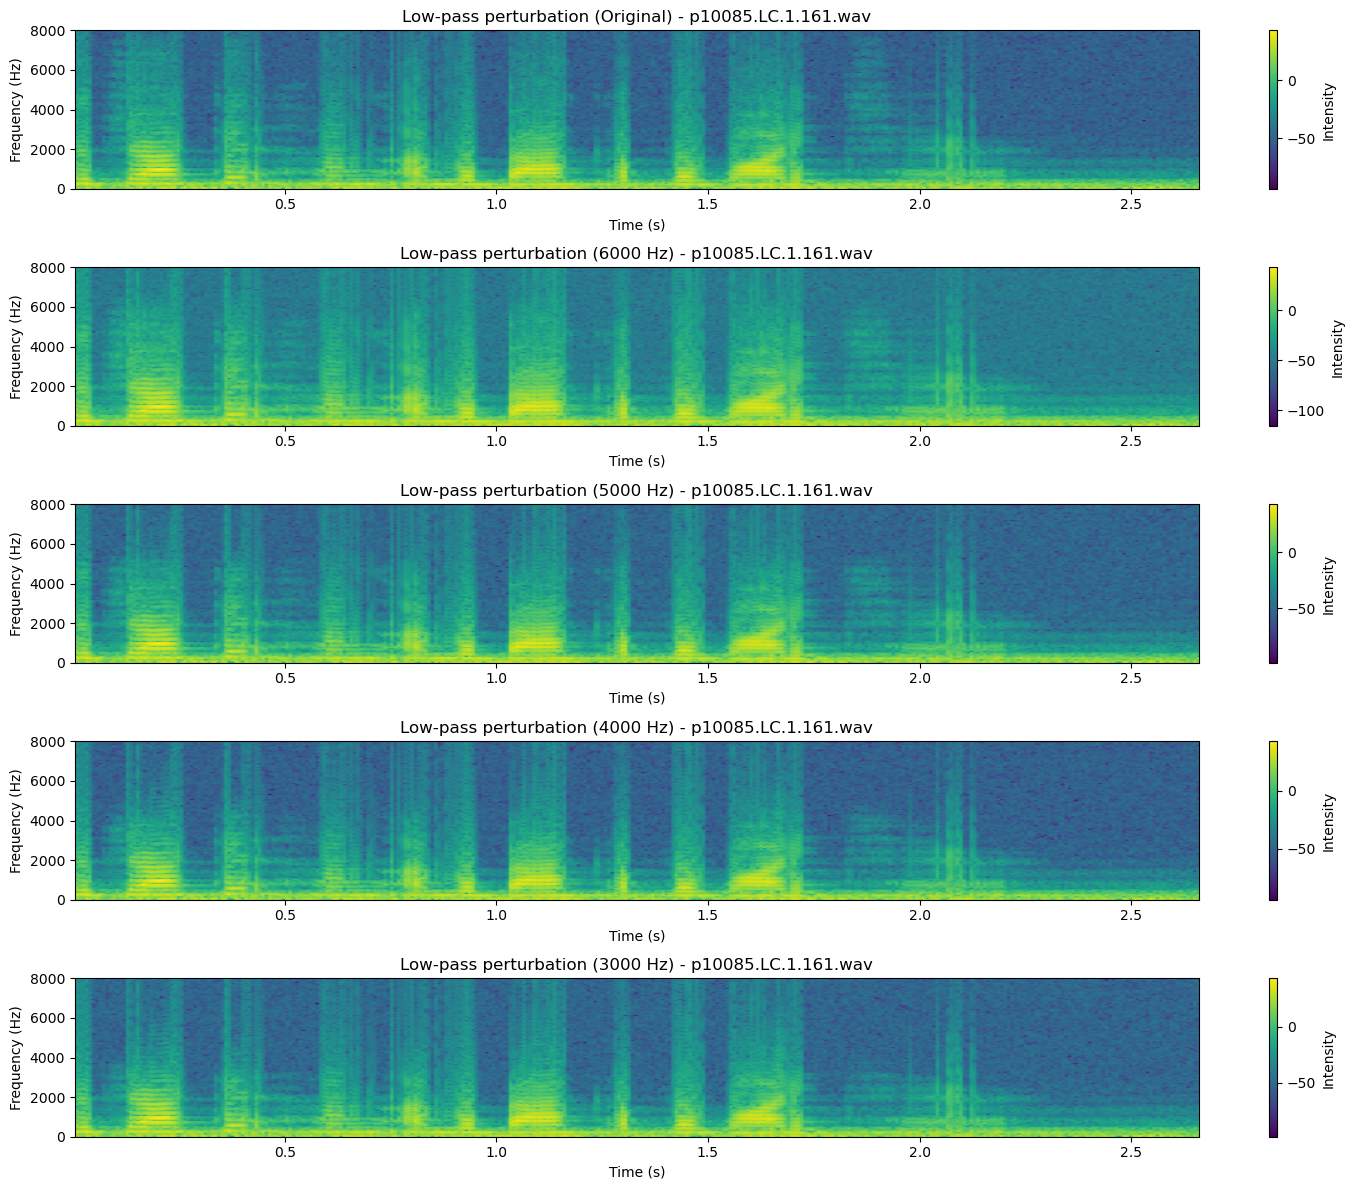

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

def get_group_suffix(dataset_name):
    """
    Get the group suffix for the output directory based on the dataset name. 
    This function maps the dataset name to a specific suffix that indicates which group of pain levels it corresponds to. 
    If the dataset name is "original", it returns an empty string, indicating that it includes all pain levels. 
    For the other dataset names, it returns a suffix that specifies the range of pain levels included in that dataset. 
    """
    
    if dataset_name == "original":
        return ""
    if dataset_name == "original_pain_group_1_to_4":
        return "_group_1_to_4"
    if dataset_name == "original_pain_group_5_to_6":
        return "_group_5_to_6"
    if dataset_name == "original_pain_group_7_to_10":
        return "_group_7_to_10"
    if dataset_name == "wiener":
        return ""
    if dataset_name == "wiener_pain_group_1_to_4":
        return "_group_1_to_4"
    if dataset_name == "wiener_pain_group_5_to_6":
        return "_group_5_to_6"
    if dataset_name == "wiener_pain_group_7_to_10":
        return "_group_7_to_10"
    raise ValueError(f"Unknown dataset_name: {dataset_name}")


def get_base_type(dataset_name):
    """
    Get the base type (original or wiener) from the dataset name. This function determines whether the dataset corresponds to the original audio files or the Wiener-filtered versions based on the prefix of the dataset name.
    It returns "original" for dataset names that start with "original" and "wiener" for those that start with "wiener". If the dataset name does not match either of these patterns, it raises a ValueError indicating an unknown dataset name.
    """
    if dataset_name.startswith("original"):
        return "original"
    if dataset_name.startswith("wiener"):
        return "wiener"
    raise ValueError(f"Unknown dataset_name: {dataset_name}")


def build_audiofiles_dir(dataset_name):
    """
    Build the directory path for the audio files based on the dataset name. This function constructs the path to the directory containing the audio files for a given dataset by combining the base type (original or wiener) with the appropriate group suffix derived from the dataset name.
    The resulting path points to the location where the audio files for the specified dataset are stored, allowing for easy access when plotting examples or applying perturbations.
    """
    base_type = get_base_type(dataset_name)
    group_suffix = get_group_suffix(dataset_name)
    return DATA_PATH / f"{base_type}{group_suffix}_audiofiles_pain"


def build_perturbation_dir(dataset_name, perturbation_type):
    """
    Build the directory path for the perturbed audio files based on the dataset name and perturbation type. This function constructs the path to the directory containing the perturbed audio files for a given dataset and perturbation type by combining the base type (original or wiener) with the appropriate group suffix derived from the dataset name and the specified perturbation type.
    The resulting path points to the location where the perturbed audio files for the specified dataset and perturbation type are stored, allowing for easy access when plotting examples or further processing.
    """
    base_type = get_base_type(dataset_name)
    group_suffix = get_group_suffix(dataset_name)
    return DATA_PATH / f"{base_type}{group_suffix}_{perturbation_type}_pain"


def plot_perturbation_example(dataset_name, participant_id, filename, perturbation_type):
    """
    Plot original/baseline + perturbed versions for one audio file.
    This function takes a dataset name, participant ID, filename, and perturbation type as input and plots the original/baseline audio signal along with its perturbed versions for the specified audio file.
    It first constructs the path to the original audio file and checks if it exists. Depending on the perturbation type, it then builds the paths to the perturbed audio files and loads them. 
    Finally, it creates a figure with subplots for each version of the audio signal (original and perturbed) and displays them using matplotlib.
    """

    input_dir = build_audiofiles_dir(dataset_name)
    original_file = input_dir / participant_id / filename

    if not original_file.exists():
        raise FileNotFoundError(f"Original/baseline file not found: {original_file}")

    if perturbation_type == "intensity":
        output_dir = build_perturbation_dir(dataset_name, "intensity")
        files = {
            "-6 dB": output_dir / "-6dB" / participant_id / filename,
            "-3 dB": output_dir / "-3dB" / participant_id / filename,
            "0 dB": original_file,
            "+3 dB": output_dir / "+3dB" / participant_id / filename,
            "+6 dB": output_dir / "+6dB" / participant_id / filename,
        }

        signals = {}
        global_min = np.inf
        global_max = -np.inf

        for label, file_path in files.items():
            if not file_path.exists():
                raise FileNotFoundError(f"File not found for {label}: {file_path}")

            sample_rate, signal = load_wav_file(file_path)
            signal = signal.astype(np.float32)
            signals[label] = (sample_rate, signal)

            global_min = min(global_min, signal.min())
            global_max = max(global_max, signal.max())

        plt.figure(figsize=(15, 12))

        for i, (label, (sample_rate, signal)) in enumerate(signals.items(), 1):
            time = np.arange(len(signal)) / sample_rate

            plt.subplot(5, 1, i)
            plt.plot(time, signal)
            plt.title(f"Intensity perturbation ({label}) - {filename}")
            plt.xlabel("Time (s)")
            plt.ylabel("Amplitude")
            plt.xlim(0, min(3, time[-1]))
            plt.ylim(global_min, global_max)
            plt.grid(True)

        plt.tight_layout()
        plt.show()
        return

    elif perturbation_type == "lowpass":
        output_dir = build_perturbation_dir(dataset_name, "lowpass")
        files = {
            "Original": original_file,
            "6000 Hz": output_dir / "low_lowpass" / participant_id / filename,
            "5000 Hz": output_dir / "medium_lowpass" / participant_id / filename,
            "4000 Hz": output_dir / "high_lowpass" / participant_id / filename,
            "3000 Hz": output_dir / "very_high_lowpass" / participant_id / filename,
        }
        title_prefix = "Low-pass perturbation"

    elif perturbation_type == "gaussian_noise":
        output_dir = build_perturbation_dir(dataset_name, "gaussian_noise")
        files = {
            "Original": original_file,
            "0.5%": output_dir / "low_gaussian_noise" / participant_id / filename,
            "2.0%": output_dir / "medium_gaussian_noise" / participant_id / filename,
            "5.0%": output_dir / "high_gaussian_noise" / participant_id / filename,
            "10.0%": output_dir / "very_high_gaussian_noise" / participant_id / filename,
        }
        title_prefix = "Gaussian noise perturbation"

    elif perturbation_type == "pink_noise":
        output_dir = build_perturbation_dir(dataset_name, "pink_noise")
        files = {
            "Original": original_file,
            "0.5%": output_dir / "low_pink_noise" / participant_id / filename,
            "2.0%": output_dir / "medium_pink_noise" / participant_id / filename,
            "5.0%": output_dir / "high_pink_noise" / participant_id / filename,
            "10.0%": output_dir / "very_high_pink_noise" / participant_id / filename,
        }
        title_prefix = "Pink noise perturbation"

    else:
        raise ValueError(
            "perturbation_type must be one of: "
            "'intensity', 'lowpass', 'gaussian_noise', 'pink_noise'"
        )

    plt.figure(figsize=(15, 12))

    for i, (label, file_path) in enumerate(files.items(), 1):
        if not file_path.exists():
            raise FileNotFoundError(f"File not found for {label}: {file_path}")

        sample_rate, signal = load_wav_file(file_path)
        signal = signal.astype(np.float32)

        plt.subplot(5, 1, i)
        plt.specgram(signal, Fs=sample_rate)
        plt.title(f"{title_prefix} ({label}) - {filename}")
        plt.xlabel("Time (s)")
        plt.ylabel("Frequency (Hz)")
        plt.ylim(0, sample_rate / 2)
        plt.colorbar(label="Intensity")

    plt.tight_layout()
    plt.show()


# Fill in the parameters for the example you want to plot
plot_perturbation_example(
    dataset_name="wiener",
    participant_id="p10085",
    filename="p10085.LC.1.161.wav",
    perturbation_type="lowpass"
)